In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.utils import resample

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [3]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [4]:
pd.DataFrame(data.data, columns=data.feature_names).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
pd.DataFrame(data.target, columns=["type"]).head()

,type
0,0
1,0
2,0
3,0
4,0


In [6]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [7]:
X = data.data
y = data.target 

In [8]:
scaler = MinMaxScaler(feature_range=(0,1))
X_ = scaler.fit_transform(data.data)

In [9]:
X = pd.DataFrame(X_, columns=data.feature_names)
y = pd.DataFrame(y, columns=["benign"])

In [11]:
test_size = 0.33
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [13]:
Xy_train = pd.concat([X_train,y_train], axis=1)

In [14]:
Xy_train_malignant = Xy_train[Xy_train.benign==0]
Xy_train_benign = Xy_train[Xy_train.benign==1]

In [18]:
Xy_train_malignant_count = Xy_train_malignant.shape[0]
Xy_train_malignant_count

153

In [19]:
Xy_train_benign_count = Xy_train_benign.shape[0]
Xy_train_benign_count

228

In [31]:
Xy_train_malignant_oversampled = resample(Xy_train_malignant,replace=True, n_samples=Xy_train_benign_count)
Xy_train_malignant_oversampled.shape

(228, 31)

In [32]:
Xy_train_malignant_undersampled = resample(Xy_train_benign, replace=True,n_samples=Xy_train_malignant_count)
Xy_train_malignant_undersampled.shape

(153, 31)

In [33]:
combined = pd.concat([Xy_train_malignant_oversampled, Xy_train_benign])

In [34]:
combined.benign.value_counts()

benign
0    228
1    228
Name: count, dtype: int64

In [35]:
y_train = combined.benign
X_train = combined.drop("benign", axis=1)

In [36]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [38]:
predictions = model.predict(X_train)

In [39]:
print(confusion_matrix(y_train, predictions))

[[222   6]
 [  3 225]]


In [40]:
accuracy_score(y_train, predictions)

0.9802631578947368

In [41]:
print(classification_report(y_train, predictions, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.99      0.97      0.98       228
      benign       0.97      0.99      0.98       228

    accuracy                           0.98       456
   macro avg       0.98      0.98      0.98       456
weighted avg       0.98      0.98      0.98       456



In [46]:
def plotRocAuc(model, X, y):

    probabilities = model.predict_proba(X)
    probabilities = probabilities[:, 1]

    fpr, tpr, thresholds = roc_curve(y, probabilities)

    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.plot(fpr, tpr, marker = ".")
    plt.text(0.75, 0.25, "AUC: " + str(round(roc_auc_score(y, probabilities),2)))

    plt.show()

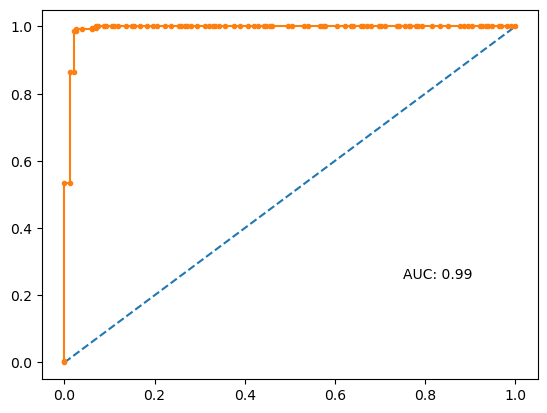

In [47]:
plotRocAuc(model, X_train, y_train)

LogisticRegression
---------------------------------
confusion matrix:
[[ 55   4]
 [  0 129]]

Accuracy: 0.9787234042553191

Classification report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        59
      benign       0.97      1.00      0.98       129

    accuracy                           0.98       188
   macro avg       0.98      0.97      0.97       188
weighted avg       0.98      0.98      0.98       188


ROC / AUC:


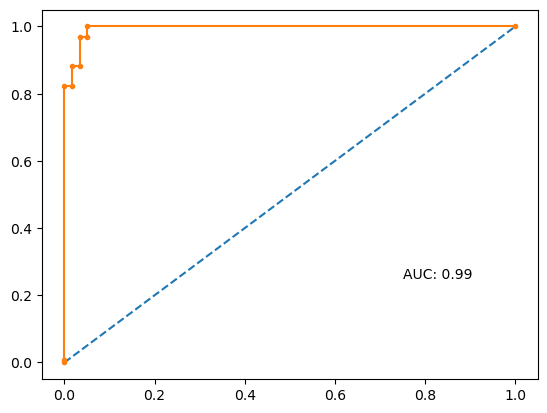

In [48]:
predictions = model.predict(X_test)

print(type(model).__name__)
print("---------------------------------")
print("confusion matrix:")
print(confusion_matrix(y_test, predictions))

print("\nAccuracy:", accuracy_score(y_test, predictions))

print("\nClassification report:")
print(classification_report(y_test, predictions, target_names=data.target_names))

print("\nROC / AUC:")
plotRocAuc(model, X_test, y_test)